# Strategier och tips för att arbeta med djupinlärning
I kursen har ni nu fått grunderna för att förstå mer avancerade djupinlärningsmetoder. I den här notebooken har jag samlat lite användbara strategier och tips för att jobba vidare med djupinlärning, bortom vad vi går igenom i kursen.


## Deep learning crash course
Bok skriven av kollegor vid institutionen, där jag också medverkat i redigeringsprocessen.
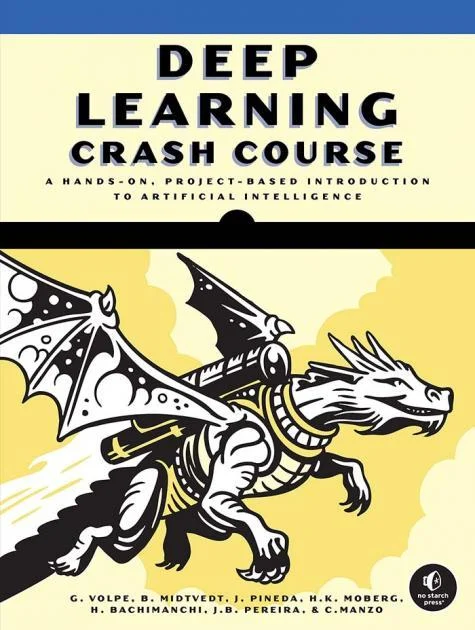

https://github.com/DeepTrackAI/DeepLearningCrashCourse


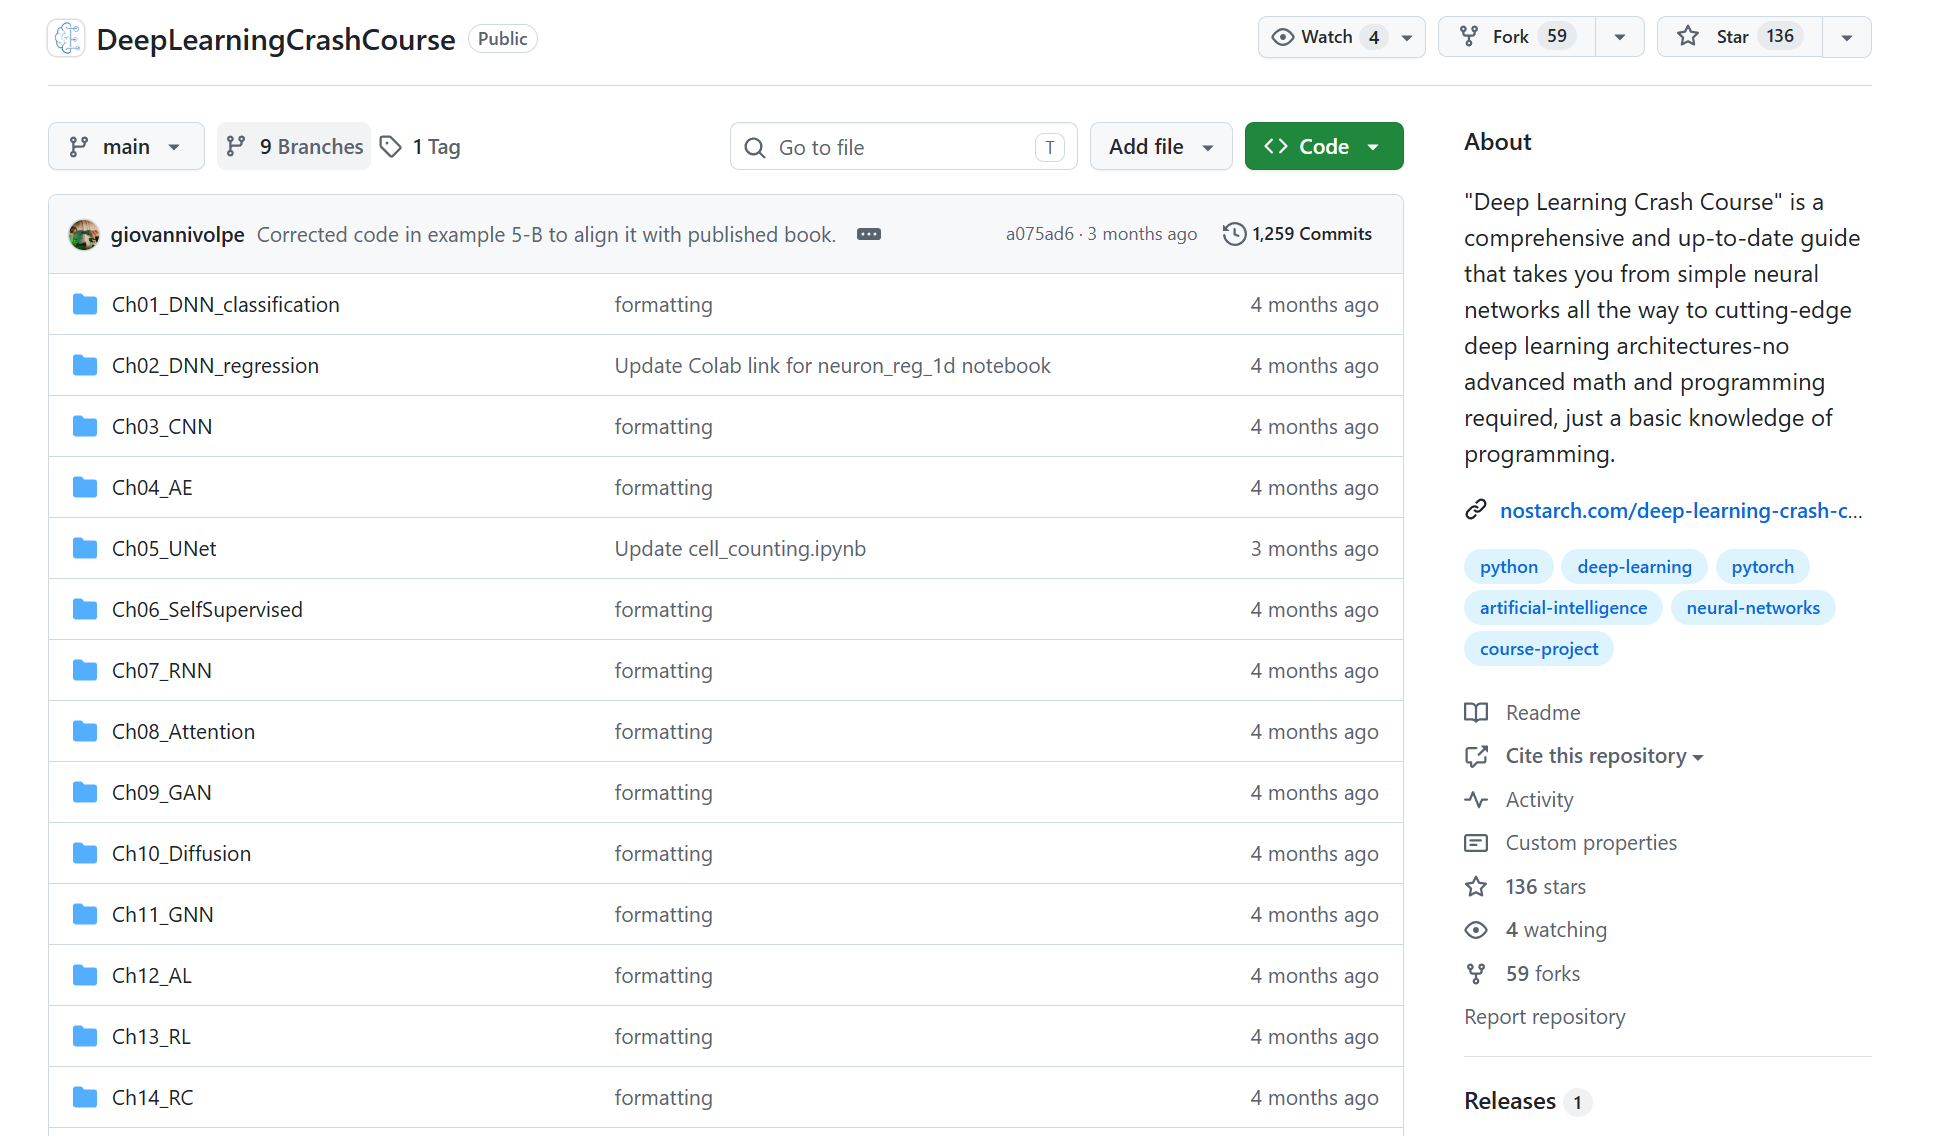

Boken avhandlar allt från grundläggande maskininlärning till teknikerna som används för att träna Chat-GPT. 

Till varje kapitel finns en notebook med exempelkod som visar hur teknikerna fungerar

Boken avhandlar också djupinlärningspaketen Deeplay och Deeptrack, som är utvecklade av oss på GU
för att underlätta träning av avancerade djupinlärningsmodeller

## Praktiska riktlinjer och tips

### 1: Vilken typ av problem försöker du lösa?
Man skiljer ofta mellan regressionsproblem och klassificeringsproblem. Vill du dela in datan i olika klasser, eller vill du förutsäga ett specifikt värde? Det avgör vilken förlustfunktion du vill använda, och hur datan ska vara formatterad vid output.
Är output från nätverket mer komplext, till exempel en bild eller en sekvens av ord, behövs ofta en typ av nätverk som kallas Encoder-Decoder (kommer till det strax)

### 2: Titta alltid på datan innan du börjar arbeta
Är din data normaliserad? Inkonsekvent normalisering är en väldigt vanlig anledning till att träning misslyckas.
Titta på några representativa datapunkter. Kan du själv göra kopplingen mellan data och label? Om ja, vilka egenskaper i datan använder du dig av för att göra din förutsägelse? Om nej, vilka egenskaper i datan gör dig osäker? Kan du designa din arkitektur och träningsstrategi för att tvinga nätverket att titta på relevanta egenskaper?

#### Nätverk försöker alltid minimera förlustfunktionen, inte lösa ditt problem!

### 3: Vilka invarianser, symmetrier och ekvivarianser finns i ditt problem?
#### Invarians
Om din uppgift är att skilja mellan bilder på katter och hundar, spelar det ingen roll var någonstans i bilden katten eller hunden är. Om uppgiften är att hitta positionen av ett objekt i en bild, finns inte samma translationinvarians.
#### Symmetri
Förväntar du dig att få samma svar om du vänder upp och ned på bilden? I så fall har du en spegelsymmetri i ditt problem, och du kan fördubbla ditt tillgängliga dataset genom att skapa en upp-och-nedvänd kopia av alla bilder.
#### Ekvivarians
Kan du förutsäga hur ditt målvärde förändras om du transformerar input på ett visst sätt? Om du till exempel translaterar en bild 2 pixlar åt vänster, vet du att objektet du försöker lokalisera också förflyttar sig två pixlar till vänster. Det är en translationsekvivarians.

#### Alla dessa går att använda på smarta sätt för att hjälpa nätverket att hitta rätt!


### Exempel från boken: Klassificering av malaria från blodprov.
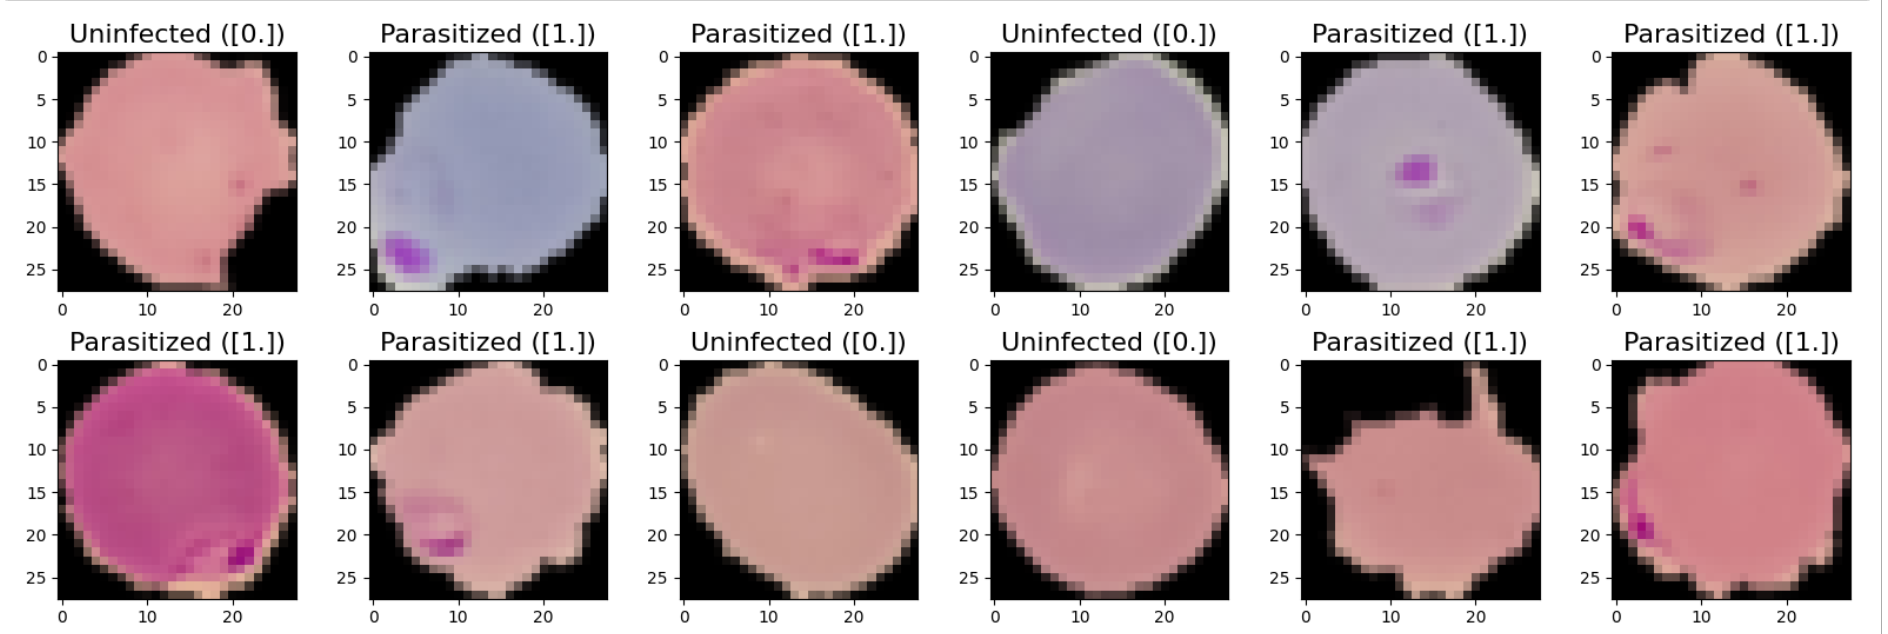

Klassificeringen beror på existensen av en prick, men är oberoende av var i bilden pricken befinner sig.

In [ ]:
conv_base = dl.ConvolutionalNeuralNetwork(
    in_channels=3, hidden_channels=[16, 16, 32], out_channels=32,
)
conv_base.blocks[2].pool.configure(torch.nn.MaxPool2d, kernel_size=2)

connector = dl.Layer(torch.nn.AdaptiveAvgPool2d, output_size=1)

dense_top = dl.MultiLayerPerceptron(
    in_features=32, hidden_features=[], out_features=1,
    out_activation=torch.nn.Sigmoid,
)

cnn = dl.Sequential(conv_base, connector, dense_top)

"AdaptiveAveragePool2d" medelvärdesbildar outputfrån varje feature i lagret till ett värde. Om storleken innan lagret är (8,8,32), blir output en vektor med storlek (1,32). "Flatten" behåller information om position, men skulle resultera i en vektor (1, 2048) istället, och kräva mycket fler parametrar för att träna.

### 4: Hur mycket träningsdata med labels finns att tillgå?
Detta avgör komplexiteten på modellen. Ju fler tillgängliga datapunkter, desto fler parametrar kan man ha i sitt nätverk, och desto mer kraftfull kan den bli.

### 5: Hur mycket träningsdata utan labels finns att tillgå?
Har du mycket data, men få labels, kan det vara möjligt att göra förprocessering som minskar komplexiteten på datan och därmed gör det möjligt att träna ett närverk ändå. Ett exempel är med hjälp av så kallade autoencoders, som vi kommer till strax